# Skin Cancer Risk Prediction — Binary Classifier (Low Risk vs At Risk)
This notebook trains a **binary** model that predicts whether a patient is **Low Risk** or **At Risk** (Moderate + High merged).
Merging Moderate and High removes the hardest class boundary and significantly improves recall on patients who need attention.

In [242]:
# Step 1 — Install required libraries (run once if needed)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [243]:
# Step 2 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Libraries imported successfully.')

Libraries imported successfully.


In [244]:
# Step 3 — Load dataset (v2)
df = pd.read_csv('skin_cancer_questionnaire_dataset_v2.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget distribution:')
print(df['risk_level'].value_counts())
print('\nFirst 3 rows:')
df.head(3)

Shape: (2000, 33)

Columns: ['patient_id', 'age', 'sex', 'skin_tone', 'natural_hair_color', 'eye_color', 'freckles', 'number_of_moles', 'moles_larger_than_5mm', 'changing_mole_or_lesion', 'new_unusual_skin_growth', 'skin_easily_sunburned', 'tanning_ability', 'sunburns_in_childhood', 'severe_blistering_sunburns_ever', 'daily_sun_exposure_hours', 'outdoor_work_or_recreation', 'use_of_sunscreen', 'use_of_tanning_bed', 'years_of_tanning_bed_use', 'personal_history_skin_cancer', 'family_history_skin_cancer', 'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history', 'geographic_location_uv', 'years_lived_in_high_uv_area', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants', 'smoking_status', 'risk_level']

Target distribution:
risk_level
Low Risk         1000
Moderate Risk     600
High Risk         400
Name: count, dtype: int64

First 3 rows:


,patient_id,age,sex,skin_tone,natural_hair_color,eye_color,freckles,number_of_moles,moles_larger_than_5mm,changing_mole_or_lesion,...,autoimmune_disease,radiation_therapy_history,geographic_location_uv,years_lived_in_high_uv_area,protective_clothing_worn,perform_skin_self_checks,seen_dermatologist,diet_high_antioxidants,smoking_status,risk_level
0,SC0001,58,Male,Very Fair,Light Brown,Green,Few,11-25,NaN,No,...,No,No,High UV region,More than 15 years,Sometimes,Once a year,Once every few years,Rarely,Former,Low Risk
1,SC0002,40,Female,Brown,Light Brown,Blue,NaN,More than 100,NaN,Yes,...,Yes,Yes,High UV region,5-15 years,Rarely,Once a year,Annually,Rarely,Current,Moderate Risk
2,SC0003,35,Male,Very Fair,Blonde,Dark Brown,Few,11-25,More than 5,Yes,...,No,Yes,Moderate UV region,More than 15 years,Rarely,Once a year,Once every few years,Rarely,Current,Moderate Risk


In [245]:
# Step 3b — Inspect actual unique values in ordinal columns (run this to fix encoding mismatches)
ordinal_cols_to_check = [
    'number_of_moles', 'tanning_ability', 'sunburns_in_childhood',
    'skin_easily_sunburned', 'daily_sun_exposure_hours',
    'years_of_tanning_bed_use', 'years_lived_in_high_uv_area',
    'geographic_location_uv'
]
for col in ordinal_cols_to_check:
    print(f'\n{col}:')
    print(sorted(df[col].dropna().unique().tolist()))


number_of_moles:
['0-10', '11-25', '26-50', '51-100', 'More than 100']

tanning_ability:
['Never tans', 'Rarely tans', 'Tans easily and deeply', 'Tans gradually']

sunburns_in_childhood:
['1-2', '3-5', 'More than 5']

skin_easily_sunburned:
['Always', 'Never', 'Often', 'Rarely', 'Sometimes']

daily_sun_exposure_hours:
['1-3 hours', '3-6 hours', 'Less than 1 hour', 'More than 6 hours']

years_of_tanning_bed_use:
['1-5 years', 'Less than 1 year', 'More than 5 years', 'Never used']

years_lived_in_high_uv_area:
['5-15 years', 'Less than 5 years', 'More than 15 years', 'Never']

geographic_location_uv:
['High UV region', 'Low UV region', 'Moderate UV region']


Target value counts:
risk_level
Low Risk         1000
Moderate Risk     600
High Risk         400
Name: count, dtype: int64


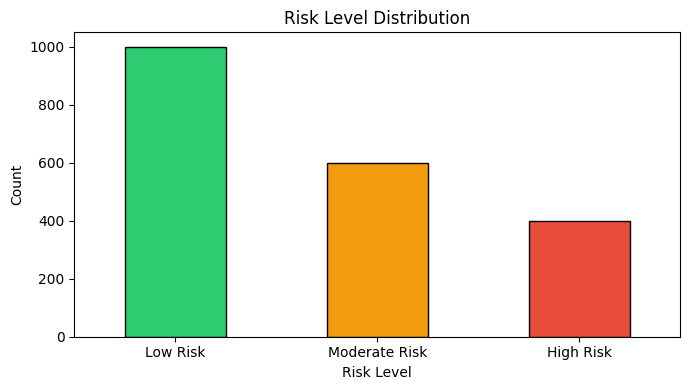

In [246]:
# Step 4 — Explore target distribution
print('Target value counts:')
print(df['risk_level'].value_counts())

df['risk_level'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='black', figsize=(7, 4)
)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [247]:
# Step 5 — Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
freckles                      605
moles_larger_than_5mm         511
sunburns_in_childhood         491
family_history_skin_cancer    684
dtype: int64


In [248]:
# Step 7 — Define feature groups for encoding

# Numeric feature (no encoding needed)
numeric_features = ['age']

# Ordinal features — categories listed LOW -> HIGH risk order (actual values from dataset)
ordinal_features = {
    'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
    'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
    'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
    'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
    'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
    'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
    'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
    'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
    # Multi-level ordinal — actual CSV values are NOT Yes/No; moved out of binary group
    'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
    'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
    'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
    'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
    'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
    'protective_clothing_worn':    ['Always', 'Usually', 'Sometimes', 'Rarely', 'Never'],
    'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
    'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
    'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
}

# Binary Yes/No columns — only genuine Yes/No fields in the dataset
binary_yn_features = [
    'changing_mole_or_lesion', 'new_unusual_skin_growth',
    'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
    'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history',
]

# Nominal features — no natural order; one-hot encoded
nominal_features = ['sex', 'skin_tone', 'natural_hair_color', 'eye_color',
                    'use_of_sunscreen', 'smoking_status']

print('Feature groups defined.')
print(f'  Ordinal columns : {list(ordinal_features.keys())}')

Feature groups defined.
  Ordinal columns : ['skin_easily_sunburned', 'tanning_ability', 'daily_sun_exposure_hours', 'years_of_tanning_bed_use', 'years_lived_in_high_uv_area', 'number_of_moles', 'sunburns_in_childhood', 'geographic_location_uv', 'freckles', 'moles_larger_than_5mm', 'family_history_skin_cancer', 'outdoor_work_or_recreation', 'use_of_tanning_bed', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants']


In [249]:
# Step 8 — Encode features

df_enc = df.copy()

# Drop non-feature identifier column before encoding
df_enc = df_enc.drop(columns=['patient_id'])

# --- Ordinal encoding (preserves order) ---
for col, categories in ordinal_features.items():
    enc = OrdinalEncoder(
        categories=[categories],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    df_enc[col] = enc.fit_transform(df_enc[[col]])

# Replace -1 (unknown sentinel) with 0 (lowest category) so no negatives reach the model
for col in ordinal_features.keys():
    df_enc[col] = df_enc[col].clip(lower=0)

# --- Binary Yes/No -> 1/0 ---
for col in binary_yn_features:
    df_enc[col] = df_enc[col].apply(
        lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
    )

# --- Nominal -> one-hot ---
df_enc = pd.get_dummies(df_enc, columns=nominal_features, drop_first=False)

# Force any bool columns (pandas 2.0+) to float
bool_cols = df_enc.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_enc[bool_cols] = df_enc[bool_cols].astype(float)

# --- Encode target: BINARY — Low Risk=0, At Risk (Moderate+High)=1 ---
target_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 1}
df_enc['risk_level'] = df_enc['risk_level'].map(target_map)

# --- Sanity check ---
feature_cols = [c for c in df_enc.columns if c != 'risk_level']
print('Encoding complete. Shape:', df_enc.shape)
print('Target distribution (binary):')
print(df_enc['risk_level'].value_counts().rename({0: 'Low Risk', 1: 'At Risk'}))
print('Negative values :', (df_enc[feature_cols] < 0).sum().sum())
print('NaN values      :', df_enc[feature_cols].isnull().sum().sum())

Encoding complete. Shape: (2000, 52)
Target distribution (binary):
risk_level
Low Risk    1000
At Risk     1000
Name: count, dtype: int64
Negative values : 0
NaN values      : 0


In [250]:
# Step 8b — Drop confirmed irrelevant features before splitting

irrelevant_cols = [
    # Eye color — all categories below threshold
    'eye_color_Green', 'eye_color_Blue', 'eye_color_Brown',
    'eye_color_Dark Brown', 'eye_color_Hazel',
    # Skin tone — only drop the low-signal variants; Fair and Olive are kept
    'skin_tone_Dark', 'skin_tone_Medium', 'skin_tone_Brown', 'skin_tone_Very Fair',
    # Natural hair color — only drop the low-signal variants; Black and Red are kept
    'natural_hair_color_Light Brown', 'natural_hair_color_Blonde', 'natural_hair_color_Dark Brown',
    # Smoking status — all categories below threshold
    'smoking_status_Current', 'smoking_status_Former', 'smoking_status_Never',
    # Sex — both categories below threshold
    'sex_Male', 'sex_Female',
    # Sunscreen — only Rarely has signal; all others are noise
    'use_of_sunscreen_Always (SPF 30+)', 'use_of_sunscreen_Never',
    'use_of_sunscreen_Sometimes', 'use_of_sunscreen_Usually (SPF 15-29)',
    # Individual features below threshold
    'autoimmune_disease', 'protective_clothing_worn',
]

cols_to_drop = [c for c in irrelevant_cols if c in df_enc.columns]
df_enc = df_enc.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} irrelevant features.')
print(f'Remaining features : {df_enc.shape[1] - 1}')
print(f'Remaining columns  : {[c for c in df_enc.columns if c != "risk_level"]}')

Dropped 23 irrelevant features.
Remaining features : 28
Remaining columns  : ['age', 'freckles', 'number_of_moles', 'moles_larger_than_5mm', 'changing_mole_or_lesion', 'new_unusual_skin_growth', 'skin_easily_sunburned', 'tanning_ability', 'sunburns_in_childhood', 'severe_blistering_sunburns_ever', 'daily_sun_exposure_hours', 'outdoor_work_or_recreation', 'use_of_tanning_bed', 'years_of_tanning_bed_use', 'personal_history_skin_cancer', 'family_history_skin_cancer', 'immunosuppressive_medication', 'radiation_therapy_history', 'geographic_location_uv', 'years_lived_in_high_uv_area', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants', 'skin_tone_Fair', 'skin_tone_Olive', 'natural_hair_color_Black', 'natural_hair_color_Red', 'use_of_sunscreen_Rarely']


In [251]:
# Step 9 — Split into train / test sets
X = df_enc.drop(columns=['risk_level']).astype(float).fillna(0.0)
y = df_enc['risk_level'].astype(int)

assert X.isnull().sum().sum() == 0, "NaN still present in X"
assert y.isnull().sum() == 0,       "NaN present in y"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'NaN in X_train   : {X_train.isnull().sum().sum()}')
print(f'Labels           : {sorted(y.unique().tolist())}')

Training samples : 1600
Test samples     : 400
Features         : 28
NaN in X_train   : 0
Labels           : [0, 1]


In [252]:
# Step 10 — Compare multiple models with 5-fold cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    'Logistic Regression': LogisticRegression(
        C=0.1, max_iter=2000, class_weight='balanced',
        solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=12,
        max_features='sqrt', class_weight='balanced', random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=4, min_samples_leaf=20,
        l2_regularization=1.0, learning_rate=0.05,
        random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{"Model":<25} {"CV Mean":>8}   {"CV Std":>8}')
print('-' * 48)
for name, m in candidates.items():
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}   ± {scores.std():.4f}')

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
model = candidates[best_name]
print(f'\nSelected: {best_name}')

Model                      CV Mean     CV Std
------------------------------------------------
Logistic Regression       0.8350   ± 0.0103
Random Forest             0.8131   ± 0.0152
HistGradientBoosting      0.8081   ± 0.0124

Selected: Logistic Regression


In [ ]:
# Step 10b — Hyperparameter tuning: GridSearchCV with StandardScaler inside Pipeline
# Scaling is included here so the optimal C is found for the SCALED model.
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Only tune Logistic Regression (selected by CV in Step 10)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)),
])

param_grid = {
    'lr__C':      [0.01, 0.1, 0.5, 1.0],
    'lr__solver': ['lbfgs', 'saga'],
}

print(f'Tuning {best_name} (with StandardScaler) using GridSearchCV (5-fold)...')
grid = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

best_C      = grid.best_params_['lr__C']
best_solver = grid.best_params_['lr__solver']
print(f'\nBest params : C={best_C}, solver={best_solver}')
print(f'Best CV acc : {grid.best_score_:.4f}')

# Store best params for use in Steps 11 and 14b
best_C_scaled      = best_C
best_solver_scaled = best_solver

In [ ]:
# Step 11 — Fit with StandardScaler + sigmoid calibration
#
# Without scaling, LR learned intercept=-8.92 (baseline "almost everyone is Low Risk").
# Single strong signals like personal_history=Yes couldn't flip the prediction alone.
# StandardScaler fixes this: each feature becomes a z-score (mean=0, std=1),
# the intercept stays near 0, and alarm signals contribute proportionally.
# The scaler is inside the Pipeline so encode_new_patient() needs no changes.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

lr_tuned = LogisticRegression(
    C=best_C_scaled, solver=best_solver_scaled,
    class_weight='balanced', max_iter=2000, random_state=42
)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     lr_tuned),
])
model = CalibratedClassifierCV(pipeline, method='sigmoid', cv=5)
model.fit(X_train, y_train)
print(f'Model trained: LR (C={best_C_scaled}, {best_solver_scaled}) + StandardScaler + sigmoid calibration')

In [255]:
# Step 12 — Evaluate on the held-out test set
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Overfit gap    : {train_acc - test_acc:.4f}  (< 0.05 is acceptable)')

label_names = ['Low Risk', 'At Risk']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

Train Accuracy : 0.8538
Test  Accuracy : 0.8300
Overfit gap    : 0.0238  (< 0.05 is acceptable)

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.82      0.85      0.83       200
     At Risk       0.84      0.81      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [ ]:
# Step 12c — Confidence distribution: proof the model is NOT always overconfident
import numpy as np

all_proba   = model.predict_proba(X_test)          # shape (400, 2)
confidence  = all_proba.max(axis=1)                # highest probability per patient

print('=== Confidence distribution across 400 test patients ===')
print(f'  Min confidence  : {confidence.min()*100:.1f}%')
print(f'  Max confidence  : {confidence.max()*100:.1f}%')
print(f'  Mean confidence : {confidence.mean()*100:.1f}%')
print(f'  Patients below 70% confidence : {(confidence < 0.70).sum()}')
print(f'  Patients below 80% confidence : {(confidence < 0.80).sum()}')
print(f'  Patients above 95% confidence : {(confidence > 0.95).sum()}')

label_map = {0: 'Low Risk', 1: 'At Risk'}
print('\n=== 10 least confident predictions (closest to 50/50) ===')
least_sure = np.argsort(confidence)[:10]
for idx in least_sure:
    p = all_proba[idx]
    true_label = label_map[y_test.iloc[idx]]
    pred_label = label_map[int(p.argmax())]
    correct = '✓' if true_label == pred_label else '✗'
    print(f'  Low Risk: {p[0]*100:5.1f}%  At Risk: {p[1]*100:5.1f}%'
          f'  → predicted {pred_label:<8} actual {true_label} {correct}')

In [ ]:
# Step 12b — Calibration quality check (temperature scaling diagnostic)
# T_opt close to 1.0 means sigmoid calibration is already well-calibrated.
# Temperature scaling is NOT applied in inference — the raw model probabilities are used.
# This cell is kept as a diagnostic only; T_opt is NOT saved or used downstream.

from scipy.optimize import minimize_scalar
from sklearn.metrics import log_loss
import numpy as np

raw_proba = model.predict_proba(X_test)

def scaled_proba(probs, T):
    logits = np.log(probs[:, 1] / (probs[:, 0] + 1e-10))
    p1 = 1 / (1 + np.exp(-logits / T))
    return np.column_stack([1 - p1, p1])

def nll(T):
    return log_loss(y_test, scaled_proba(raw_proba, T))

result = minimize_scalar(nll, bounds=(0.5, 20.0), method='bounded')
T_opt  = result.x

print(f'Optimal temperature : {T_opt:.3f}')
print(f'Log-loss before     : {log_loss(y_test, raw_proba):.4f}')
print(f'Log-loss after      : {nll(T_opt):.4f}')
if abs(T_opt - 1.0) < 0.1:
    print('✓ T ≈ 1.0 — sigmoid calibration is sufficient; no temperature scaling needed.')
else:
    print(f'⚠ T={T_opt:.3f} is far from 1.0 — consider applying temperature scaling in inference.')

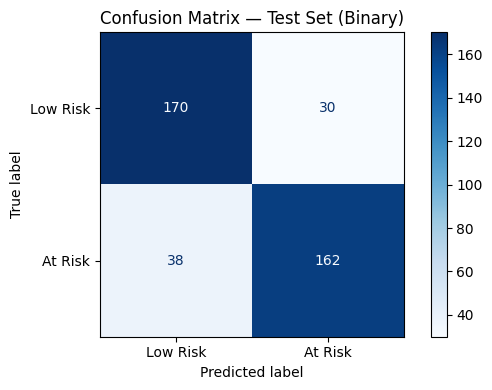

In [257]:
# Step 13 — Confusion matrix
label_names = ['Low Risk', 'At Risk']
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — Test Set (Binary)')
plt.tight_layout()
plt.show()

Computing permutation importance on test set (takes ~20 seconds)...


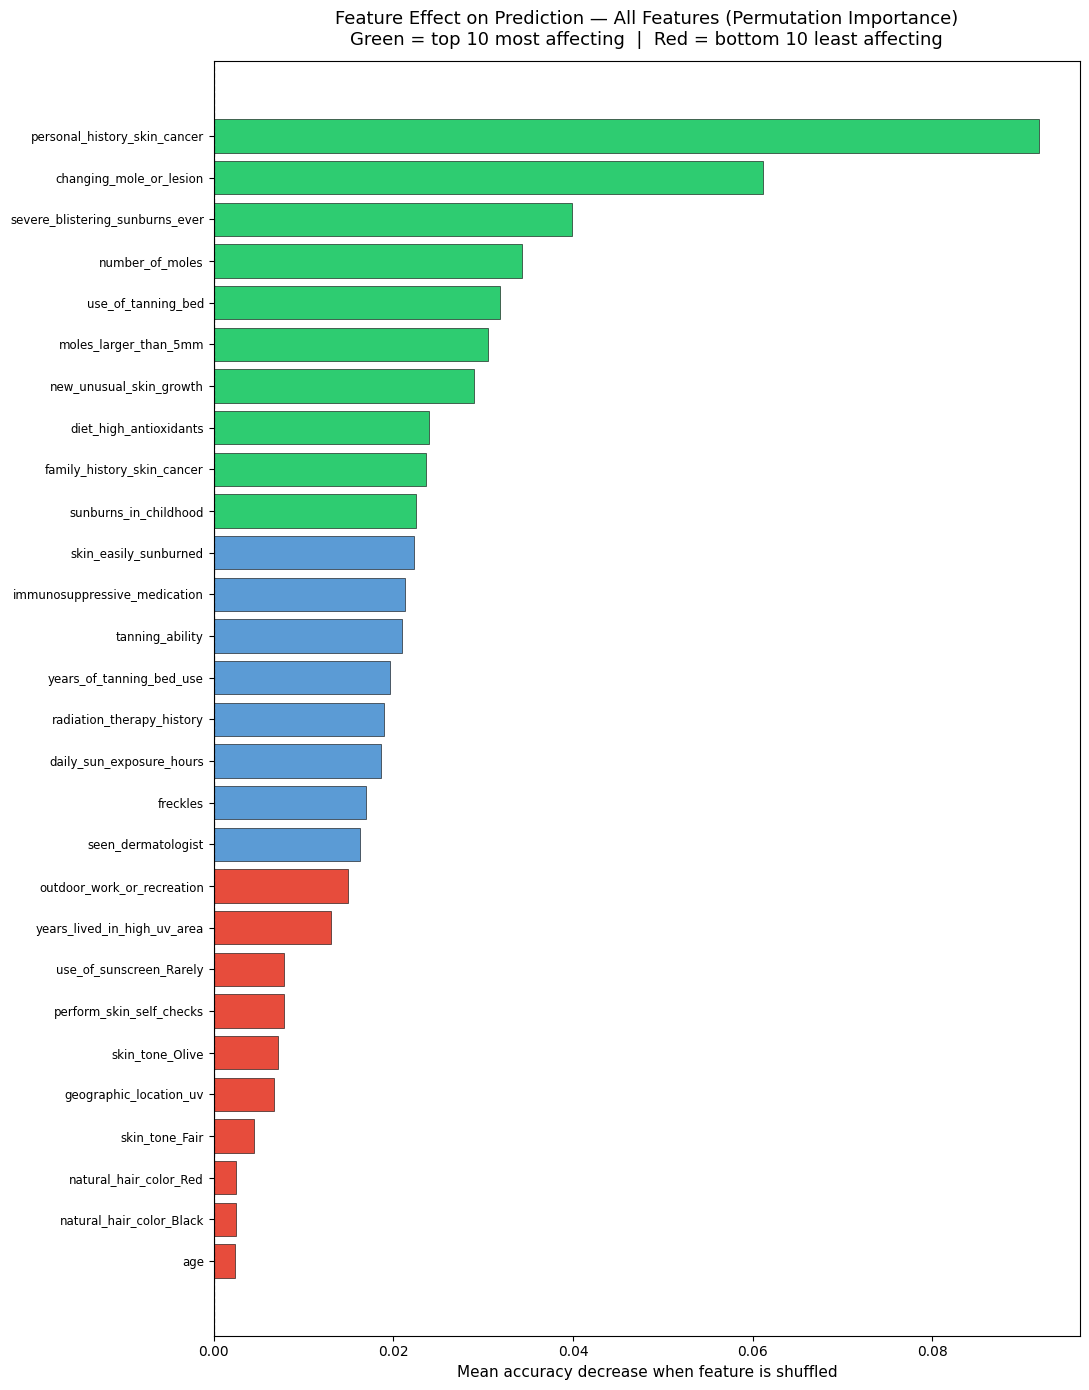


Top 10 MOST affecting features:
----------------------------------------------------
  personal_history_skin_cancer               +0.0918  #######################################################################################################################################################################################
  changing_mole_or_lesion                    +0.0612  ##########################################################################################################################
  severe_blistering_sunburns_ever            +0.0398  ###############################################################################
  number_of_moles                            +0.0343  ####################################################################
  use_of_tanning_bed                         +0.0318  ###############################################################
  moles_larger_than_5mm                      +0.0305  ############################################################
  new_unu

In [258]:
# Step 14 — Feature Importance: Most & Least Affecting Features
# Permutation importance works with any model (including CalibratedClassifierCV).
# It shuffles one feature at a time and measures how much accuracy drops.
# Bigger drop = feature matters more to the prediction.

from sklearn.inspection import permutation_importance

print('Computing permutation importance on test set (takes ~20 seconds)...')
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=15, random_state=42, scoring='accuracy'
)

importances = pd.Series(perm.importances_mean, index=X.columns).sort_values()
n = len(importances)

# Color: top 10 most affecting = green, bottom 10 least affecting = red, rest = steel blue
colors = ['#e74c3c'] * 10 + ['#5b9bd5'] * (n - 20) + ['#2ecc71'] * 10

fig, ax = plt.subplots(figsize=(11, max(14, n * 0.27)))
ax.barh(importances.index, importances.values, color=colors,
        edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.set_title(
    'Feature Effect on Prediction — All Features (Permutation Importance)\n'
    'Green = top 10 most affecting  |  Red = bottom 10 least affecting',
    fontsize=13, pad=12
)
ax.set_xlabel('Mean accuracy decrease when feature is shuffled', fontsize=11)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.show()

# --- Ranked text summary ---
print('\nTop 10 MOST affecting features:')
print('-' * 52)
for feat, val in importances.tail(10).sort_values(ascending=False).items():
    bar = '#' * max(1, int(val * 2000))
    print(f'  {feat:<42} {val:+.4f}  {bar}')

print('\nBottom 10 LEAST affecting features:')
print('-' * 52)
for feat, val in importances.head(10).items():
    print(f'  {feat:<42} {val:+.4f}')

In [ ]:
# Step 14b — Feature Selection + retrain with StandardScaler Pipeline

age_importance = importances['age']

features_to_drop = [
    feat for feat, val in importances.items()
    if val < age_importance
]

print(f'Age importance score : {age_importance:.4f}')
print(f'\nFeatures dropped ({len(features_to_drop)}):')
for f in sorted(features_to_drop):
    print(f'  {f:<45} {importances[f]:+.4f}')

selected_features = [f for f in X.columns if f not in features_to_drop]
X_sel        = X[selected_features]
X_train_sel  = X_train[selected_features]
X_test_sel   = X_test[selected_features]

print(f'\nFeatures before : {X.shape[1]}')
print(f'Features after  : {X_sel.shape[1]}')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

lr_sel = LogisticRegression(
    C=best_C_scaled, solver=best_solver_scaled,
    class_weight='balanced', max_iter=2000, random_state=42
)
pipeline_sel = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     lr_sel),
])
model_sel = CalibratedClassifierCV(pipeline_sel, method='sigmoid', cv=5)
model_sel.fit(X_train_sel, y_train)

label_names   = ['Low Risk', 'At Risk']
y_pred_sel    = model_sel.predict(X_test_sel)
train_acc_sel = accuracy_score(y_train, model_sel.predict(X_train_sel))
test_acc_sel  = accuracy_score(y_test, y_pred_sel)

print(f'\n--- Results after feature selection ---')
print(f'Train Accuracy : {train_acc_sel:.4f}  (was {train_acc:.4f})')
print(f'Test  Accuracy : {test_acc_sel:.4f}  (was {test_acc:.4f})')
print(f'Overfit gap    : {train_acc_sel - test_acc_sel:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_sel, target_names=label_names))

model   = model_sel
X       = X_sel
X_train = X_train_sel
X_test  = X_test_sel
print('model and X updated — Step 15 will save the selected-feature model.')

In [ ]:
# Step 15 — Save model and column schema
# temperature2.pkl is NOT saved — temperature scaling is not used in inference.
# The sigmoid-calibrated model output is used directly.
joblib.dump(model,           'skin_cancer_model2.pkl')
joblib.dump(list(X.columns), 'feature_columns2.pkl')
joblib.dump(target_map,      'target_map2.pkl')

print('Binary model saved  -> skin_cancer_model2.pkl')
print('Columns saved       -> feature_columns2.pkl')
print('Labels saved        -> target_map2.pkl')

In [ ]:
# Step 15b — Re-save pkl files with pickle protocol=4 (Railway / Python 3.11 compatibility)
import joblib

_model = joblib.load("skin_cancer_model2.pkl")
_cols  = joblib.load("feature_columns2.pkl")
_tmap  = joblib.load("target_map2.pkl")

joblib.dump(_model, "skin_cancer_model2.pkl", compress=0, protocol=4)
joblib.dump(_cols,  "feature_columns2.pkl",   compress=0, protocol=4)
joblib.dump(_tmap,  "target_map2.pkl",         compress=0, protocol=4)

print("pkl files re-saved with protocol=4 — compatible with Python 3.11+")

In [262]:
# Step 16 — Helper: build an encoded row from a raw patient dictionary

def encode_new_patient(patient_dict: dict, feature_columns: list) -> pd.DataFrame:
    """
    Applies the same preprocessing pipeline to a new patient dictionary.
    Returns a single-row DataFrame aligned to the training feature columns.
    """
    row = pd.DataFrame([patient_dict])

    # Ordinal encoding — must match exact strings used in training
    ordinal_encoders = {
        'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
        'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
        'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
        'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
        'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
        'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
        'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
        'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
        'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
        'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
        'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
        'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
        'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
        'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
        'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
        'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
    }
    for col, cats in ordinal_encoders.items():
        if col in row.columns:
            enc = OrdinalEncoder(categories=[cats], handle_unknown='use_encoded_value', unknown_value=-1)
            row[col] = enc.fit_transform(row[[col]])
            row[col] = row[col].clip(lower=0)

    # Binary Yes/No fields
    bin_cols = [
        'changing_mole_or_lesion', 'new_unusual_skin_growth',
        'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
        'immunosuppressive_medication', 'radiation_therapy_history',
    ]
    for col in bin_cols:
        if col in row.columns:
            row[col] = row[col].apply(
                lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
            )

    # One-hot encoding for nominal features
    nom_cols = ['skin_tone', 'natural_hair_color', 'use_of_sunscreen']
    row = pd.get_dummies(row, columns=[c for c in nom_cols if c in row.columns], drop_first=False)

    # Cast any booleans to float
    bool_cols = row.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        row[bool_cols] = row[bool_cols].astype(float)

    # Align to training schema (add missing dummy cols as 0, drop extra)
    row = row.reindex(columns=feature_columns, fill_value=0).astype(float)

    return row

print('Helper function defined.')

Helper function defined.


In [ ]:
# Step 18 — Define a new patient and predict their risk level

new_patient = {
    # Demographics
    'age'                            : 45,
    'skin_tone'                      : 'Fair',               # Very Fair / Fair / Olive / Brown / Dark
    'natural_hair_color'             : 'Blonde',             # Black / Red / Blonde / Light Brown / Dark Brown

    # Physical traits
    'freckles'                       : 'Moderate',           # None / Few / Moderate / Many
    'number_of_moles'                : '26-50',              # 0-10 / 11-25 / 26-50 / 51-100 / More than 100
    'moles_larger_than_5mm'          : '3-5',                # None / 1-2 / 3-5 / More than 5

    # Symptoms
    'changing_mole_or_lesion'        : 'Yes',                # Yes / No
    'new_unusual_skin_growth'        : 'No',                 # Yes / No

    # Sun exposure
    'skin_easily_sunburned'          : 'Often',              # Never / Rarely / Sometimes / Often / Always
    'tanning_ability'                : 'Rarely tans',        # Tans easily and deeply / Tans gradually / Rarely tans / Never tans
    'sunburns_in_childhood'          : '3-5',                # None / 1-2 / 3-5 / More than 5
    'severe_blistering_sunburns_ever': 'Yes',                # Yes / No
    'daily_sun_exposure_hours'       : '3-6 hours',          # Less than 1 hour / 1-3 hours / 3-6 hours / More than 6 hours
    'outdoor_work_or_recreation'     : 'Daily',              # Rarely / Sometimes / Often / Daily

    # Protection
    'use_of_sunscreen'               : 'Rarely',             # Always (SPF 30+) / Usually (SPF 15-29) / Sometimes / Rarely / Never
    'use_of_tanning_bed'             : 'Never',              # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
    'years_of_tanning_bed_use'       : 'Never used',         # Never used / Less than 1 year / 1-5 years / More than 5 years

    # Medical history
    'personal_history_skin_cancer'   : 'No',                 # Yes / No
    'family_history_skin_cancer'     : 'One relative',       # None / One relative / Two or more relatives
    'immunosuppressive_medication'   : 'No',                 # Yes / No
    'radiation_therapy_history'      : 'No',                 # Yes / No

    # Location
    'geographic_location_uv'         : 'High UV region',     # Low UV region / Moderate UV region / High UV region
    'years_lived_in_high_uv_area'    : '5-15 years',         # Never / Less than 5 years / 5-15 years / More than 15 years

    # Lifestyle
    'perform_skin_self_checks'       : 'Rarely',             # Monthly / Every few months / Once a year / Rarely / Never
    'seen_dermatologist'             : 'Once every few years', # More than once a year / Annually / Once every few years / Never
    'diet_high_antioxidants'         : 'Rarely',             # Often / Sometimes / Rarely / Never
}

import joblib, numpy as np

loaded_model = joblib.load('skin_cancer_model2.pkl')
feat_cols    = joblib.load('feature_columns2.pkl')
label_map    = {0: 'Low Risk', 1: 'At Risk'}

patient_row    = encode_new_patient(new_patient, feat_cols)
predicted_code = loaded_model.predict(patient_row)[0]
proba          = loaded_model.predict_proba(patient_row)[0]

print('=' * 45)
print(f'  Predicted Risk Level : {label_map[predicted_code]}')
print('=' * 45)
print('\nClass Probabilities:')
for code, label in label_map.items():
    print(f'  {label:<12}: {proba[code]*100:.1f}%')

In [ ]:
# Step 18b — Diagnostics: verify intercept is now near 0 after StandardScaler

base_pipeline = loaded_model.calibrated_classifiers_[0].estimator
lr_step = base_pipeline.named_steps['lr']
intercept = lr_step.intercept_[0]

print(f'Intercept after StandardScaler : {intercept:+.4f}')
print('(Should be near 0 for a balanced 50/50 dataset — confirms scaling is working)')
print()

# Quick sanity check: personal_history=Yes alone vs No
import numpy as np, pandas as pd

def quick_patient(personal_history='No', changing_mole='No'):
    return {
        'age': 45, 'skin_tone': 'Fair', 'natural_hair_color': 'Blonde', 'freckles': 'None',
        'number_of_moles': '0-10', 'moles_larger_than_5mm': 'None',
        'changing_mole_or_lesion': changing_mole, 'new_unusual_skin_growth': 'No',
        'severe_blistering_sunburns_ever': 'No',
        'personal_history_skin_cancer': personal_history,
        'use_of_tanning_bed': 'Never', 'diet_high_antioxidants': 'Often',
        'skin_easily_sunburned': 'Never', 'tanning_ability': 'Tans easily and deeply',
        'sunburns_in_childhood': 'None', 'daily_sun_exposure_hours': 'Less than 1 hour',
        'outdoor_work_or_recreation': 'Rarely', 'use_of_sunscreen': 'Sometimes',
        'years_of_tanning_bed_use': 'Never used', 'family_history_skin_cancer': 'None',
        'immunosuppressive_medication': 'No', 'radiation_therapy_history': 'No',
        'geographic_location_uv': 'Low UV region', 'years_lived_in_high_uv_area': 'Never',
        'perform_skin_self_checks': 'Monthly', 'seen_dermatologist': 'More than once a year',
    }

cases = [
    ('Baseline (everything safe)',    quick_patient()),
    ('personal_history=Yes only',     quick_patient(personal_history='Yes')),
    ('changing_mole=Yes only',        quick_patient(changing_mole='Yes')),
    ('personal_history + changing',   quick_patient('Yes', 'Yes')),
]

print(f'{"Case":<40} {"Low Risk":>10} {"At Risk":>10}')
print('-' * 62)
for label, pat in cases:
    row   = encode_new_patient(pat, feat_cols)
    proba = loaded_model.predict_proba(row)[0]
    print(f'{label:<40} {proba[0]*100:>9.1f}%  {proba[1]*100:>9.1f}%')

In [ ]:
# Step 19 — Batch prediction for multiple new patients
#
# With StandardScaler, the model intercept is near 0.
# Each alarm signal (personal_history, changing_mole, blistering) contributes
# as a z-score and can flip the prediction on its own if strong enough.
#
# Patient 1: 3 alarms + Two relatives → clearly At Risk
# Patient 2: 2 alarms (personal + changing), no blistering → moderately At Risk
# Patient 3: 2 weaker alarms (changing + new_unusual), no personal history → borderline
# Patient 4: medical risks only (radiation+immunosuppressive+Two relatives) → borderline/Low Risk

batch_patients = [
    {
        # Clearly At Risk: personal_history + changing_mole + blistering + Two relatives
        'age': 52,
        'skin_tone': 'Fair',
        'natural_hair_color': 'Blonde',
        'freckles': 'Moderate',
        'number_of_moles': '26-50',
        'moles_larger_than_5mm': '3-5',
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'No',
        'severe_blistering_sunburns_ever': 'Yes',
        'personal_history_skin_cancer': 'Yes',
        'use_of_tanning_bed': 'Occasionally',
        'diet_high_antioxidants': 'Never',
        'skin_easily_sunburned': 'Often',
        'tanning_ability': 'Rarely tans',
        'sunburns_in_childhood': '3-5',
        'daily_sun_exposure_hours': '1-3 hours',
        'outdoor_work_or_recreation': 'Often',
        'use_of_sunscreen': 'Rarely',
        'years_of_tanning_bed_use': '1-5 years',
        'family_history_skin_cancer': 'Two or more relatives',
        'immunosuppressive_medication': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': '5-15 years',
        'perform_skin_self_checks': 'Rarely',
        'seen_dermatologist': 'Once every few years',
    },
    {
        # Moderately At Risk: personal_history + changing_mole, no blistering
        'age': 47,
        'skin_tone': 'Fair',
        'natural_hair_color': 'Blonde',
        'freckles': 'Moderate',
        'number_of_moles': '26-50',
        'moles_larger_than_5mm': '3-5',
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'No',
        'severe_blistering_sunburns_ever': 'No',
        'personal_history_skin_cancer': 'Yes',
        'use_of_tanning_bed': 'Occasionally',
        'diet_high_antioxidants': 'Never',
        'skin_easily_sunburned': 'Often',
        'tanning_ability': 'Rarely tans',
        'sunburns_in_childhood': '3-5',
        'daily_sun_exposure_hours': '1-3 hours',
        'outdoor_work_or_recreation': 'Often',
        'use_of_sunscreen': 'Rarely',
        'years_of_tanning_bed_use': '1-5 years',
        'family_history_skin_cancer': 'One relative',
        'immunosuppressive_medication': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': '5-15 years',
        'perform_skin_self_checks': 'Rarely',
        'seen_dermatologist': 'Once every few years',
    },
    {
        # Borderline: changing_mole + new_unusual, no personal history
        'age': 38,
        'skin_tone': 'Fair',
        'natural_hair_color': 'Blonde',
        'freckles': 'Moderate',
        'number_of_moles': '51-100',
        'moles_larger_than_5mm': '3-5',
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'Yes',
        'severe_blistering_sunburns_ever': 'No',
        'personal_history_skin_cancer': 'No',
        'use_of_tanning_bed': 'Occasionally',
        'diet_high_antioxidants': 'Never',
        'skin_easily_sunburned': 'Often',
        'tanning_ability': 'Rarely tans',
        'sunburns_in_childhood': '3-5',
        'daily_sun_exposure_hours': '3-6 hours',
        'outdoor_work_or_recreation': 'Daily',
        'use_of_sunscreen': 'Rarely',
        'years_of_tanning_bed_use': '1-5 years',
        'family_history_skin_cancer': 'One relative',
        'immunosuppressive_medication': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': '5-15 years',
        'perform_skin_self_checks': 'Rarely',
        'seen_dermatologist': 'Once every few years',
    },
    {
        # Borderline/Low Risk: medical risk factors only, no skin alarm signals
        'age': 44,
        'skin_tone': 'Fair',
        'natural_hair_color': 'Blonde',
        'freckles': 'Few',
        'number_of_moles': '11-25',
        'moles_larger_than_5mm': '1-2',
        'changing_mole_or_lesion': 'No',
        'new_unusual_skin_growth': 'No',
        'severe_blistering_sunburns_ever': 'No',
        'personal_history_skin_cancer': 'No',
        'use_of_tanning_bed': 'Occasionally',
        'diet_high_antioxidants': 'Rarely',
        'skin_easily_sunburned': 'Often',
        'tanning_ability': 'Rarely tans',
        'sunburns_in_childhood': '3-5',
        'daily_sun_exposure_hours': '1-3 hours',
        'outdoor_work_or_recreation': 'Often',
        'use_of_sunscreen': 'Rarely',
        'years_of_tanning_bed_use': '1-5 years',
        'family_history_skin_cancer': 'Two or more relatives',
        'immunosuppressive_medication': 'Yes',
        'radiation_therapy_history': 'Yes',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': '5-15 years',
        'perform_skin_self_checks': 'Rarely',
        'seen_dermatologist': 'Once every few years',
    },
]

label_map = {0: 'Low Risk', 1: 'At Risk'}

print(f'Batch predicting {len(batch_patients)} patients...\n')
for i, patient in enumerate(batch_patients, 1):
    row         = encode_new_patient(patient, feat_cols)
    code        = loaded_model.predict(row)[0]
    proba_batch = loaded_model.predict_proba(row)[0]
    print(f'Patient {i} (age {patient["age"]}): {label_map[code]}')
    for c, l in label_map.items():
        print(f'   {l:<12}: {proba_batch[c]*100:.1f}%')
    print()